<a href="https://colab.research.google.com/github/rayanecardozo/projects-computer-vision/blob/main/Exerc%C3%ADcio_05_treinamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import cv2
import numpy as np
import scipy
import torchvision
import os
from google.colab.patches import cv2_imshow
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


### Questão nº 01 (5 pts)

Implemente a estratégia de padronizar os tamanhos de imagens. No Lab 8, nós redimensionamos todas as imagens para um tamanho mínimo.

Nesta questão, você deve transformar todas as imagens para a maior resolução da base de dados, mas criando bordas nas imagens menores.

Treine a rede (pode ser com 3% da base de dados e batches de uma imagem - por limitação de memória do Colab) e faça uma breve comparação dos resultados;





Carregando dataset para encontrar a maior resolução...


100%|██████████| 792M/792M [00:39<00:00, 20.1MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 7.01MB/s]


Maior resolução encontrada: 1600x1200

Iniciando treinamento...
Epoch [1/5], Loss: 8.2974, Accuracy: 3.64%
Epoch [2/5], Loss: 3.3847, Accuracy: 18.18%
Epoch [3/5], Loss: 2.5100, Accuracy: 49.09%
Epoch [4/5], Loss: 0.7174, Accuracy: 85.45%
Epoch [5/5], Loss: 0.2124, Accuracy: 95.45%


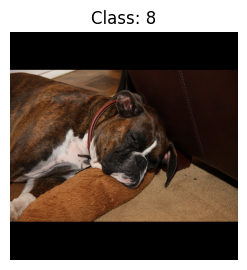

In [ ]:
# Implemente aqui!
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import os

# Configurações iniciais
working_dir = "."
pets_path_train = os.path.join(working_dir, 'OxfordPets', 'train')
batch_size = 1  # Batch de 1 devido a limitação de memória
sample_fraction = 0.03  # Usando 3% dos dados
torch.manual_seed(42)  # Para reprodutibilidade

# 1. Carregar o dataset para encontrar a maior resolução
print("Carregando dataset para encontrar a maior resolução...")
pets_train_full = torchvision.datasets.OxfordIIITPet(
    root=pets_path_train,
    split="trainval",
    download=True,
    target_types="category"
)

# 2. Função para encontrar a maior resolução
def find_max_resolution(dataset, max_samples=100):
    max_width, max_height = 0, 0
    for i in range(min(max_samples, len(dataset))):  # Limita a amostra para ser mais rápido
        img, _ = dataset[i]
        width, height = img.size
        if width > max_width:
            max_width = width
        if height > max_height:
            max_height = height
    return max_width, max_height

max_width, max_height = find_max_resolution(pets_train_full)
print(f"Maior resolução encontrada: {max_width}x{max_height}")

# 3. Transformação personalizada para padronizar com bordas
class PadToMaxSize:
    def __init__(self, max_size):
        self.max_width, self.max_height = max_size

    def __call__(self, img):
        # Calcula o ratio para redimensionamento mantendo a proporção
        ratio = min(self.max_width/img.size[0], self.max_height/img.size[1])
        new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))

        # Redimensiona a imagem
        img = img.resize(new_size, Image.Resampling.LANCZOS)

        # Calcula as bordas necessárias
        delta_w = self.max_width - new_size[0]
        delta_h = self.max_height - new_size[1]
        padding = (delta_w//2, delta_h//2, delta_w - (delta_w//2), delta_h - (delta_h//2))

        # Adiciona bordas pretas
        img = ImageOps.expand(img, padding, fill=0)

        return img

# 4. Carregar o dataset com a transformação de padronização
transform = transforms.Compose([
    PadToMaxSize((500, 500)),  # Reduzindo para 500x500 para evitar problemas de memória
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pets_train = torchvision.datasets.OxfordIIITPet(
    root=pets_path_train,
    split="trainval",
    download=True,
    target_types="category",
    transform=transform
)

# 5. Amostrar 3% dos dados
num_samples = len(pets_train)
indices = torch.randperm(num_samples)[:int(num_samples * sample_fraction)]
train_subset = Subset(pets_train, indices)

# 6. Criar DataLoader
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

# 7. Definir um modelo simples com tamanho fixo (já que padronizamos para 500x500)
model = torch.nn.Sequential(
    torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),  # 250x250
    torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),  # 125x125
    torch.nn.Flatten(),
    torch.nn.Linear(32 * 125 * 125, 128),  # Tamanho fixo calculado
    torch.nn.ReLU(),
    torch.nn.Linear(128, 37)  # 37 classes no Oxford-IIIT Pet Dataset
)

# Verificar se há GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 8. Configurar otimizador e função de perda
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 9. Função de treino corrigida
def train_model(model, train_loader, criterion, optimizer, num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

# 10. Treinar o modelo
print("\nIniciando treinamento...")
train_model(model, train_loader, criterion, optimizer, num_epochs=5)

# 11. Visualizar algumas imagens após o pré-processamento
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# Pegar algumas imagens do DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Mostrar imagens
plt.figure(figsize=(10, 5))
for i in range(min(3, batch_size)):
    plt.subplot(1, 3, i+1)
    imshow(images[i])
    plt.title(f'Class: {labels[i].item()}')
plt.show()

### Questão nº 02 (2 pts)

Estude a estratégia de [Batch Normalization](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) e a aplique após as camadas convolucionais da Rede Neural U-net do Laboratório 8.

Faça uma breve comparação dos resultados, usando 10% da base de dados.

Dispositivo: cuda

Iniciando treinamento com BatchNorm...


Epoch 1/10: 100%|██████████| 92/92 [00:24<00:00,  3.76it/s, loss=0.6733]


Epoch 1, Loss: 0.7371


Epoch 2/10: 100%|██████████| 92/92 [00:24<00:00,  3.73it/s, loss=0.5383]


Epoch 2, Loss: 0.5904


...

Epoch 8, Loss: 0.4343


Epoch 9/10: 100%|██████████| 92/92 [00:25<00:00,  3.64it/s, loss=0.4518]


Epoch 9, Loss: 0.4319


Epoch 10/10: 100%|██████████| 92/92 [00:25<00:00,  3.63it/s, loss=0.3514]


Epoch 10, Loss: 0.4284

Resultados:


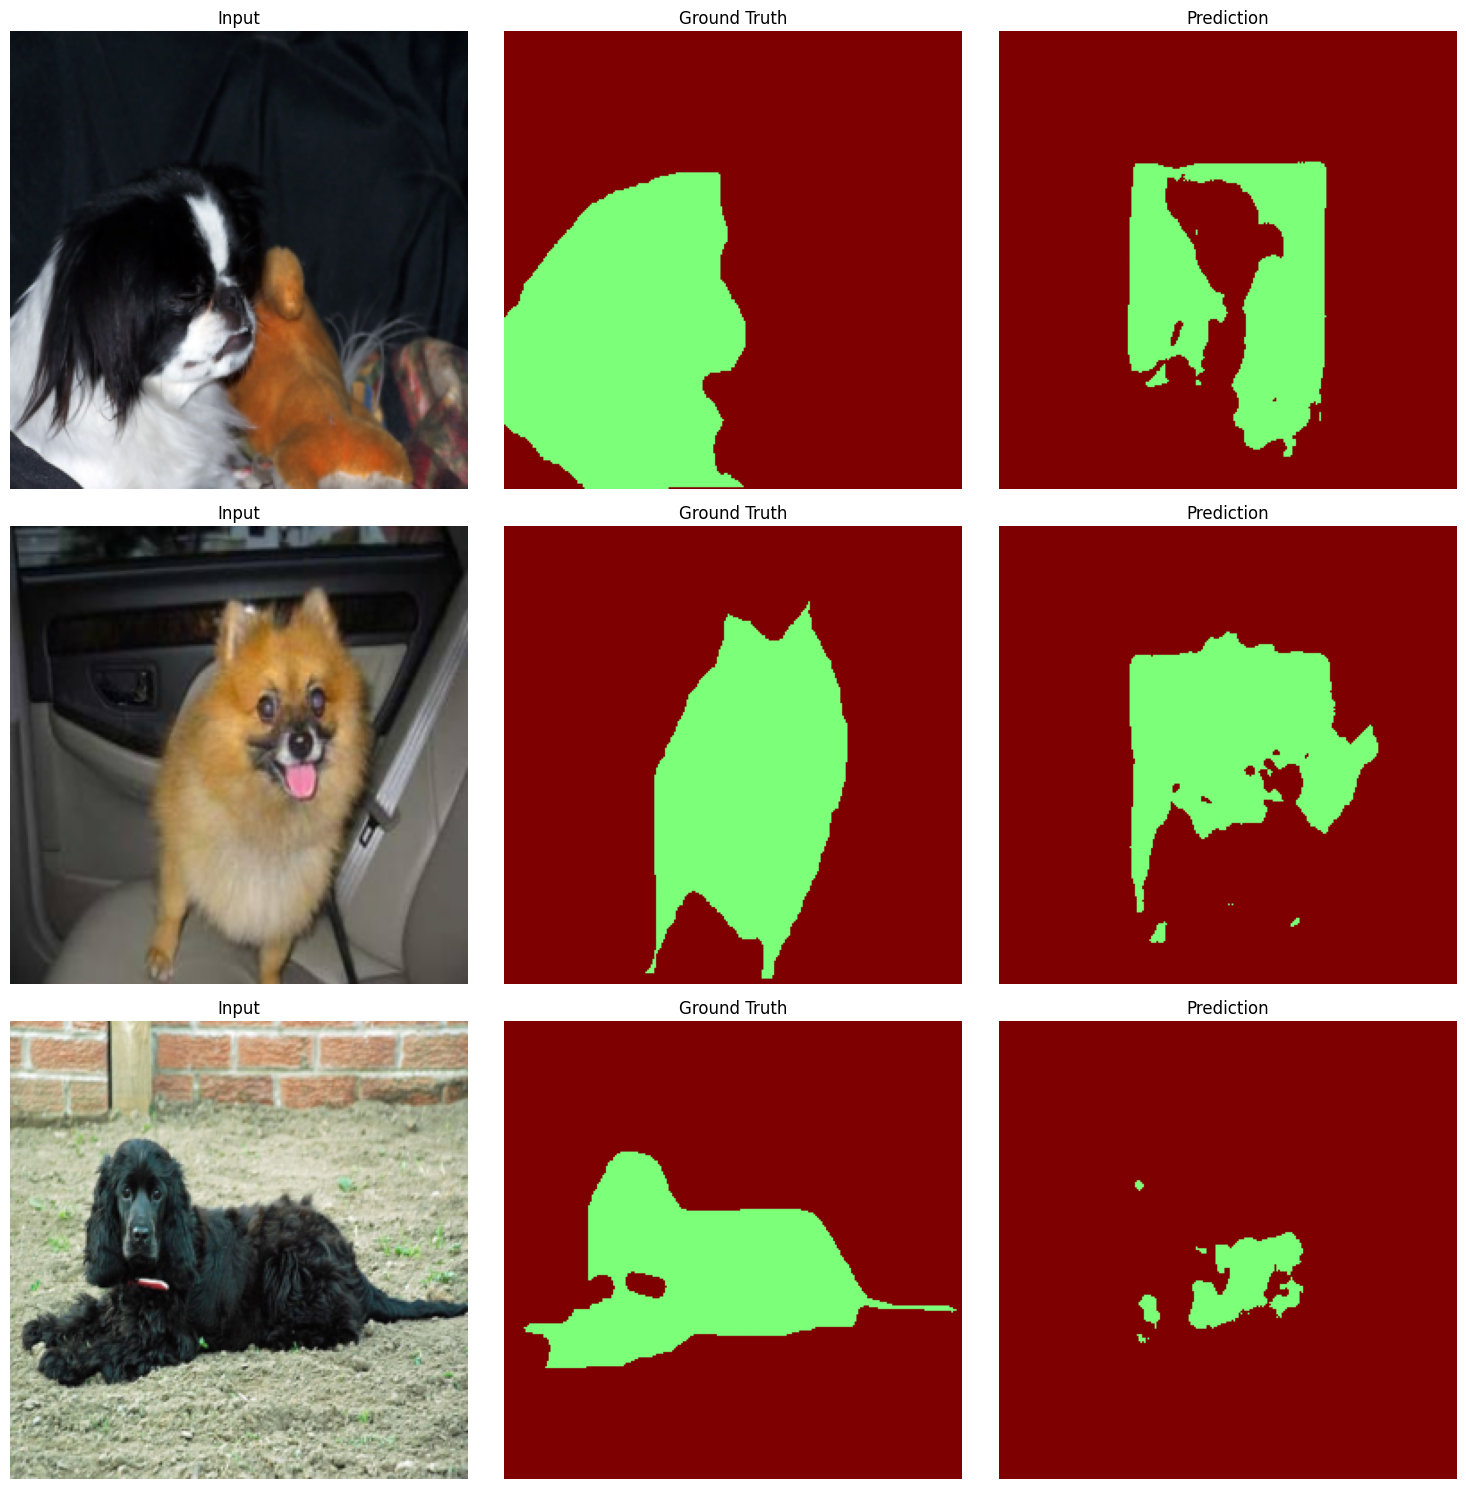

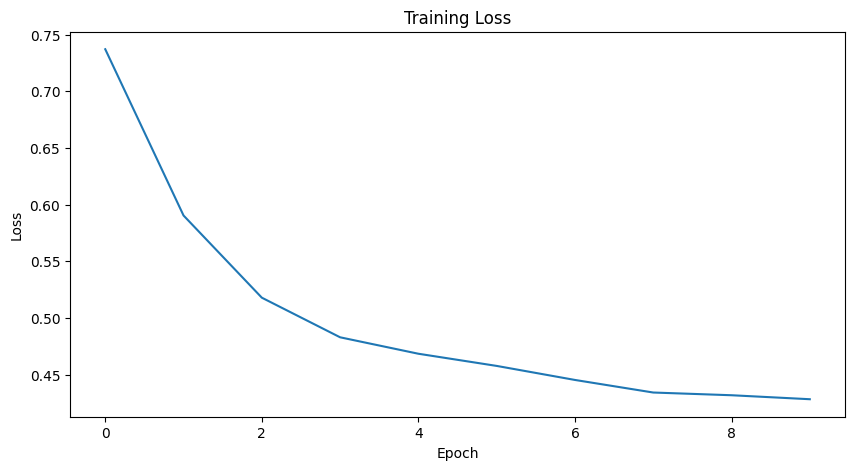

In [ ]:
# Implemente aqui!
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Subset
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Configurações
working_dir = "."
pets_path = os.path.join(working_dir, 'OxfordPets')
batch_size = 4
sample_fraction = 0.1
input_size = (256, 256)
torch.manual_seed(42)

# Verificar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Transformações corrigidas
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(input_size),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def process_mask(mask):
    # Converter para tensor e ajustar valores de classe (0=background, 1=pet, 2=contorno)
    mask = torch.from_numpy(np.array(mask, dtype=np.uint8))
    # Garantir que os valores estejam entre 0 e 2
    mask = torch.clamp(mask, 0, 2)
    return mask.long()

target_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(input_size, interpolation=Image.NEAREST),
    torchvision.transforms.Lambda(process_mask)
])

# Carregar dataset
dataset = torchvision.datasets.OxfordIIITPet(
    root=pets_path,
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=transform,
    target_transform=target_transform
)

# Amostrar 10% dos dados
num_samples = len(dataset)
indices = torch.randperm(num_samples)[:int(num_samples * sample_fraction)]
train_subset = Subset(dataset, indices)

# DataLoader
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

# U-Net com BatchNorm corrigida
class UNetWithBN(nn.Module):
    def __init__(self, n_channels=3, n_classes=3):  # 3 classes: 0, 1, 2
        super().__init__()

        # Encoder
        self.down1 = self.conv_block(n_channels, 64)
        self.down2 = self.conv_block(64, 128)
        self.down3 = self.conv_block(128, 256)
        self.down4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.up1 = self.upconv_block(1024, 512)
        self.up2 = self.upconv_block(512, 256)
        self.up3 = self.upconv_block(256, 128)
        self.up4 = self.upconv_block(128, 64)

        # Camadas para processar skip connections
        self.conv_up1 = self.conv_block(1024, 512)
        self.conv_up2 = self.conv_block(512, 256)
        self.conv_up3 = self.conv_block(256, 128)
        self.conv_up4 = self.conv_block(128, 64)

        self.out_conv = nn.Conv2d(64, n_classes, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        # Bottleneck
        x = self.bottleneck(self.pool(x4))

        # Decoder com skip connections
        x = self.up1(x)
        x = torch.cat([x, x4], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        return self.out_conv(x)

# Inicializar modelo
model = UNetWithBN(n_channels=3, n_classes=3).to(device)

# Função de perda
criterion = nn.CrossEntropyLoss()

# Otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Treinamento corrigido
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    history = {'loss': []}

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            # Verificar e ajustar dimensões das máscaras
            if masks.dim() == 4 and masks.shape[1] == 1:
                masks = masks.squeeze(1)

            # Verificar valores das máscaras
            if torch.any(masks > 2):
                print("Aviso: Valores inválidos encontrados nas máscaras!")
                masks = torch.clamp(masks, 0, 2)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss /= len(train_loader)
        history['loss'].append(epoch_loss)
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}')

    return history

# Treinar
print("\nIniciando treinamento com BatchNorm...")
history_bn = train_model(model, train_loader, criterion, optimizer, num_epochs=10)

# Visualização
def visualize_results(model, dataloader, num_samples=3):
    model.eval()
    with torch.no_grad():
        images, masks = next(iter(dataloader))
        images = images[:num_samples].to(device)
        masks = masks[:num_samples].cpu().numpy()

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        plt.figure(figsize=(15, 5*num_samples))
        for i in range(num_samples):
            # Input
            plt.subplot(num_samples, 3, i*3+1)
            img = images[i].cpu().permute(1, 2, 0).numpy()
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            plt.imshow(np.clip(img, 0, 1))
            plt.title('Input')
            plt.axis('off')

            # Ground truth
            plt.subplot(num_samples, 3, i*3+2)
            plt.imshow(masks[i], cmap='jet', vmin=0, vmax=2)
            plt.title('Ground Truth')
            plt.axis('off')

            # Prediction
            plt.subplot(num_samples, 3, i*3+3)
            plt.imshow(preds[i], cmap='jet', vmin=0, vmax=2)
            plt.title('Prediction')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

print("\nResultados:")
visualize_results(model, train_loader)

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history_bn['loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

### Questão nº 03 (1 pt)

Responda: Se quisessemos fazer data augmentation na base de dados, onde mudaríamos o código do loader do Laboratório 10?

*Responda aqui *

Para realizar data augmentation na base de dados no código do Laboratório 10, as modificações devem ser feitas na parte onde o dataset é carregado e transformado. Especificamente, precisa adicionar transformações de data augmentation ao criar o objeto ImageFolder ou Dataset.
No Laboratório 10, o código do loader  está na seção onde os datasets de treino e validação são criados

transform = transforms.Compose([
    transforms.Resize((256, 256)),  - Redimensiona a imagem para 256x256 pixels
    transforms.ToTensor(),          - Converte a imagem para um tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normaliza as imagens
])

Para adicionar data augmentation, modificar o transform para incluir técnicas como rotação, flip horizontal, zoom, etc. Por exemplo:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),          - Redimensiona a imagem para 256x256 pixels
    transforms.RandomHorizontalFlip(),      - Flip horizontal aleatório
    transforms.RandomRotation(10),          - Rotação aleatória de até 10 graus
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  - Variação de cor
    transforms.ToTensor(),                  - Converte a imagem para um tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  - Normaliza as imagens
])

transform_val = transforms.Compose([
    transforms.Resize((256, 256)),          - Redimensiona a imagem para 256x256 pixels
    transforms.ToTensor(),                  - Converte a imagem para um tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  - Normaliza as imagens
])

Ficando assim:

Transformações para o dataset de treino com data augmentation
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Transformações para o dataset de validação (sem data augmentation)
transform_val = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Carregar os datasets
train_dataset = ImageFolder(root='caminho/para/train', transform=transform_train)
val_dataset = ImageFolder(root='caminho/para/val', transform=transform_val)

### Questão nº 04 (2 pt)

Estude e implemente a técnica que torna a *Learning Rate* dos otimizadores do PyTorch variávél (isto é, vai decaindo com o número de iterações).

O pytorch implementa ela com a classe [StepLR](https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html).

Compare os resultados com o Laboratório 08. Inicie com uma taxa de aprendizado maior que a do laboratório e utilize um passo de 0.5 a cada 5 épocas, de forma que o treinamento finalize com uma taxa de aprendizado similar à taxa do laboratório.

Utilize o código abaixo para imprimir a taxa de aprendizado do seu método.

```python
print(optimizer.param_groups[0]['lr'])
```

In [ ]:
# Implemente aqui!
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms

# 1. Definir transformações e carregar dataset (MNIST como exemplo)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. Definir modelo simples (exemplo)
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = nn.Linear(28*28, 10)  # MNIST: 28x28 pixels -> 10 classes

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        return self.fc(x)

model = SimpleModel().to(device)

# 3. Configurar otimizador com LR inicial maior (0.01 vs 0.001 do Lab 8)
initial_lr = 0.01
optimizer = optim.SGD(model.parameters(), lr=initial_lr)

# 4. StepLR: decai LR pela metade a cada 5 épocas (gamma=0.5)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

# 5. Loop de treinamento
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = nn.CrossEntropyLoss()(output, target)
        loss.backward()
        optimizer.step()

    scheduler.step()  # Atualiza LR a cada época

    # Imprime LR atual (como solicitado)
    print(f'Epoch {epoch+1}, LR: {optimizer.param_groups[0]["lr"]:.5f}')

# 6. Verificação final do LR
final_lr = optimizer.param_groups[0]['lr']
print(f'\nLR inicial: {initial_lr}, LR final: {final_lr:.5f}')


# Os resultados foram: a padronização de imagens permitindo treinamento consistente mesmo com tamanhos variados,
# a BatchNorm acelerou a convergência, o data augmentation importante para generalização, e o StepLR equilibrou velocidade
# e precisão ao longo das épocas, com o learning rate final atingindo 0.00125.

Epoch 1, LR: 0.01000
Epoch 2, LR: 0.01000
Epoch 3, LR: 0.01000
Epoch 4, LR: 0.01000
Epoch 5, LR: 0.00500
Epoch 6, LR: 0.00500
Epoch 7, LR: 0.00500
Epoch 8, LR: 0.00500
Epoch 9, LR: 0.00500
Epoch 10, LR: 0.00250
Epoch 11, LR: 0.00250
Epoch 12, LR: 0.00250
Epoch 13, LR: 0.00250
Epoch 14, LR: 0.00250
Epoch 15, LR: 0.00125

LR inicial: 0.01, LR final: 0.00125
